In [4]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from os import listdir
from os.path import isfile, join
from sklearn.decomposition import PCA

from transformers import ViTImageProcessor, ViTModel
from PIL import Image, ImageDraw
import requests

from transformers import AutoModel

import timm
import torch
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform


In [5]:


model_string = 'google/vit-large-patch16-224-in21k'
# model_string = 'timm/vit_large_patch14_clip_224.openai'
model_name = str.split(model_string, '/')[1]

images_variations = [f for f in glob.glob("images_variations/*.jpg")]

for image_filename_with_extension in images_variations:
    image_filename_with_extension = str.split(image_filename_with_extension, '/')[1]
    image_filename = str.split(image_filename_with_extension, '.')[0]
    image = Image.open('images_variations/' + image_filename_with_extension)

    
    processor = ViTImageProcessor.from_pretrained(model_string)
    model = ViTModel.from_pretrained(model_string)
    # model = AutoModel.from_pretrained("timm/vit_large_patch14_clip_224.openai", dtype="auto")

    inputs = processor(images=image, return_tensors="pt")
    outputs = model(**inputs, output_hidden_states=True)

    # hidden_states is a tuple of (embeddings + all layer outputs)
    all_hidden_states = outputs.hidden_states
    
    # Take the last 4 states, which are the most interesting
    for state in (0, 1, 2, 3):
        # last_hidden_state = outputs.last_hidden_state
        X = all_hidden_states[state].detach().numpy()[0][1:,:] #Tensor with activations from the this layer

        pca = PCA(n_components=1)
        X_reduced = pca.fit_transform(X)
        doe_die_image = X_reduced.reshape(14,14)

        fig = plt.figure(frameon=False)
        fig.set_size_inches(6,6)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)

        ax.imshow(doe_die_image,cmap='viridis', aspect='auto', interpolation=None)
        fig.savefig('images_heatmap/' + image_filename + '_heatmap_' + model_name + '_layer_' + str(state) + '.jpg')
        plt.close()
        # plt.show()

        # This part is for combining the heatmap with the input picture
        img = Image.open('images_variations/' + image_filename_with_extension).convert("RGBA")
        x,y = img.size
        img2 = Image.open('images_heatmap/' + image_filename + '_heatmap_' + model_name + '_layer_' + str(state) + '.jpg').convert("RGBA").resize((x,y))

        img.putalpha(225)
        img2.putalpha(45)

        img3 = Image.alpha_composite(img, img2)
        img3.save('images_result_combined/' + image_filename + '_' + model_name + '_layer_' + str(state) + '.png')


Loading weights: 100%|██████████| 392/392 [00:00<00:00, 11638.89it/s]


In [43]:
from transformers import AutoImageProcessor

# Load the processor for a timm model
processor = AutoImageProcessor.from_pretrained("timm/vit_large_patch14_clip_224.openai")

# Load from Hub 🔥
model = timm.create_model(
    'timm/vit_large_patch14_clip_224.openai',
    pretrained=True,
    num_classes=0,
    global_pool=''
)

# Set model to eval mode for inference
model.eval()

# Create Transform
transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))

# Images of vases, faces, or anything in between
image = processor(Image.open('faces_vase_color.jpg').convert('RGB'))
# image = torch.unsqueeze(image, dim=0)

x = model.forward_features(**image, output_hidden_states=True)
# model.forward_features(image)

# Process PIL image with transforms and add a batch dimension
# x = transform(image)

# torch.Size([3, 224, 224])

# pca = PCA(n_components=1)
# X_reduced = pca.fit_transform(x[1])

x.shape

# X = x.detach().numpy()[0][1:,:] #Tensor with activations from the this layer

# pca = PCA(n_components=1)
# X_reduced = pca.fit_transform(X)
# X_reduced.shape

# doe_die_image = X_reduced.reshape(16,16)

# fig = plt.figure(frameon=False)
# fig.set_size_inches(6,6)
# ax = plt.Axes(fig, [0., 0., 1., 1.])
# ax.set_axis_off()
# fig.add_axes(ax)

# ax.imshow(doe_die_image,cmap='viridis', aspect='auto', interpolation=None)


# fig.savefig('clip_heatmap.jpg')
# plt.close()



TypeError: VisionTransformer.forward_features() got an unexpected keyword argument 'pixel_values'

AttributeError: 'Tensor' object has no attribute 'hidden_states'

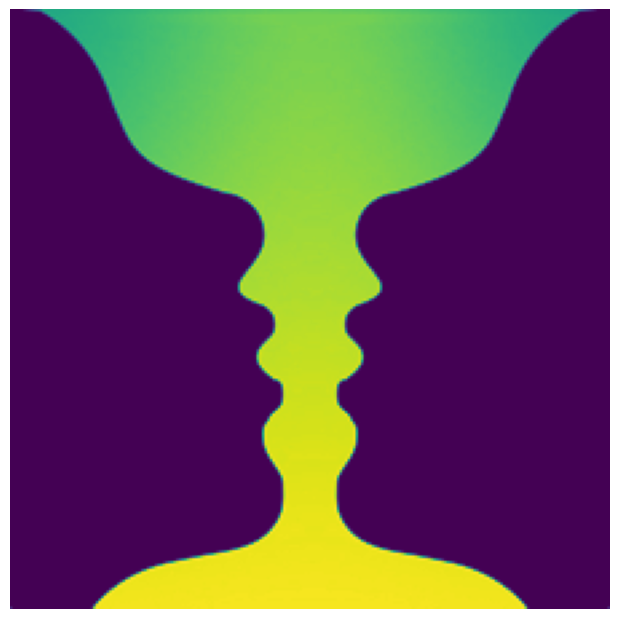

In [27]:
doe_die_image = x[0,:,:]

fig = plt.figure(frameon=False)
fig.set_size_inches(6,6)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(doe_die_image,cmap='viridis', aspect='auto', interpolation=None)
fig.savefig('veesesfeeses_result.jpg')

In [3]:
# Test with multiple layers

model_string = 'google/vit-large-patch16-224-in21k'
# model_string = 'timm/vit_large_patch14_clip_224.openai'
model_name = str.split(model_string, '/')[1]

# Testing multiple layers. Here with images_original

images_variations = [f for f in listdir('images_original') if isfile(join('images_original', f))]

for image_filename_with_extension in images_variations:

    image_filename = str.split(image_filename_with_extension, '.')[0]
    image = Image.open('images_original/' + image_filename_with_extension)

    
    processor = ViTImageProcessor.from_pretrained(model_string)
    model = ViTModel.from_pretrained(model_string)

    inputs = processor(images=image, return_tensors="pt")
    outputs = model(**inputs, output_hidden_states=True)

    # hidden_states is a tuple of (embeddings + all layer outputs)
    all_hidden_states = outputs.hidden_states

    # Example: Totally 25 layers: take middle layer 13
    # Totally 24 layers: take 12
    if len(all_hidden_states) % 2:
        middle_layer_number = int((len(all_hidden_states) + 1 )/ 2)
    else:
        middle_layer_number = int(len(all_hidden_states) / 2)
        # or maybe +1?
    middle_layer_output = all_hidden_states[middle_layer_number]

    # use all hidden states
    for state in range(len(all_hidden_states)):

        # last_hidden_state = outputs.last_hidden_state
        X = all_hidden_states[state].detach().numpy()[0][1:,:] #Tensor with activations from the this layer

        pca = PCA(n_components=1)
        X_reduced = pca.fit_transform(X)
        doe_die_image = X_reduced.reshape(14,14)

        fig = plt.figure(frameon=False)
        fig.set_size_inches(6,6)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)

        ax.imshow(doe_die_image,cmap='viridis', aspect='auto', interpolation=None)


        # cb = plt.colorbar() 
        # cb.remove() 
        # plt.axis('off') # For the figure we don't need all the axis and legends
        fig.savefig('images_heatmap/' + image_filename + '_heatmap_' + model_name + '_layer_' + str(state) + '.jpg')
        plt.close()
        # plt.show()

        # This part is for combining the heatmap with the input picture
        img = Image.open('images_original/' + image_filename_with_extension).convert("RGBA")
        x,y = img.size
        img2 = Image.open('images_heatmap/' + image_filename + '_heatmap_' + model_name + '_layer_' + str(state) + '.jpg').convert("RGBA").resize((x,y))

        img.putalpha(225)
        img2.putalpha(45)

        img3 = Image.alpha_composite(img, img2)
        img3.save('results_multiple_layers/' + image_filename + '_' + model_name + '_layer_' + str(state) + '.png')


Loading weights: 100%|██████████| 392/392 [00:00<00:00, 15605.68it/s]


In [ ]:
# CLIP Model

import torch
import timm
m = timm.create_model('timm/vit_large_patch14_clip_224.openai', pretrained=True)
plaatje = Image.open('faces_vase_color.jpg').convert('RGB').resize((244,244))

transform = create_transform(**resolve_data_config(m.pretrained_cfg, model=m))

# o = m.forward_features(plaatje)

o = transform(plaatje)

print(f'Shape: {o.shape}')

Shape: torch.Size([3, 224, 224])


In [13]:

doe_die_image = o[0]

fig = plt.figure(frameon=False)
fig.set_size_inches(6,6)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(doe_die_image,cmap='viridis', aspect='auto', interpolation=None)
fig.savefig('veesesfeeses_result.jpg')


NameError: name 'plt' is not defined

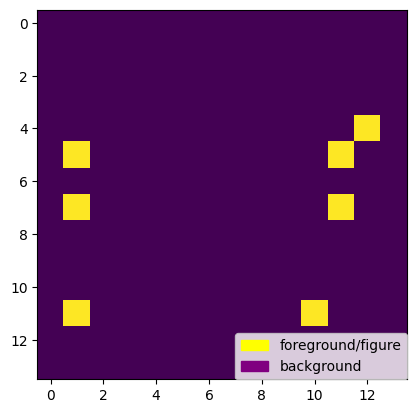

In [ ]:


## color map and labels
t = 1 ## alpha value
cmap = {0:[1.0,1.0,0.0],1:[0.5,0.0,0.5]}
labels = {0:'foreground/figure',1:'background'}
arrayShow = np.where(
    doe_die_image < 0,
    1,
    0,)
## create patches as legend
patches =[mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

plt.imshow(arrayShow)
plt.legend(handles=patches, loc=4, borderaxespad=0.)
plt.show()
